## 02 작업내용
1. 파일별 cycle 요약 생성
2. 전체 cycle 번호 만들기
3. capacity 계산
4. 이상값 확인
5. 최종 저장

## 02 체크 사항

1. Excel 파일 25개를 모두 읽었는가?
2. 모든 파일에 Channel_1-008 시트가 있었는가?
3. 필수 컬럼 누락이 없었는가?
4. 전체 cycle 번호가 중복 없이 증가하는가?
5. capacity_ah가 cycle별 1Ah 근처의 합리적인 값인가?
6. capacity_ah <= 0인 row가 있는가?
7. soh 계산 전 단계로 사용할 수 있는 깨끗한 cycle-level 테이블인가?
8. CSV와 Parquet이 모두 저장됐는가?
9. CSV와 Parquet을 다시 읽었을 때 row 수와 컬럼명이 같은가?

In [18]:
from pathlib import Path
from datetime import datetime
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# 충·방전 상태 판정 기준입니다.
CURRENT_THRESHOLD_A = 0.1

# 정상적인 완전 방전 cycle은 약 2.7V cutoff에 도달합니다.
DISCHARGE_CUTOFF_MAX_V = 2.8

# 주변 cycle 대비 충·방전 시간이 75% 미만이면
# 비표준 시험 cycle 후보로 분류합니다.
DURATION_RATIO_MIN = 0.75
DURATION_WINDOW = 11

In [20]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "calce" / "CS2" / "CS2_35"
CSV_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "csv" / "battery_cycles.csv"
PARQUET_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "paraquet" / "battery_cycles.parquet"

CELL_ID = "CS2_35"
CHANNEL_SHEET = "Channel_1-008"

required_cols = [
    "Data_Point",
    "Test_Time(s)",
    "Step_Time(s)",
    "Step_Index",
    "Cycle_Index",
    "Current(A)",
    "Voltage(V)",
    "Charge_Capacity(Ah)",
    "Discharge_Capacity(Ah)",
]

In [21]:
def parse_cs2_35_date(path: Path) -> datetime:
    # Example: CS2_35_10_15_10.xlsx -> 2010-10-15
    stem = path.stem
    parts = stem.split("_")

    month = int(parts[-3])
    day = int(parts[-2])
    year = 2000 + int(parts[-1])

    return datetime(year, month, day)

In [22]:
files = sorted(RAW_DIR.glob("*.xlsx"), key=parse_cs2_35_date)

print("raw dir:", RAW_DIR)
print("file count:", len(files))
files[:5], files[-5:]

raw dir: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35
file count: 25


([PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_8_17_10.xlsx'),
  PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_8_18_10.xlsx'),
  PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_8_19_10.xlsx'),
  PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_8_30_10.xlsx'),
  PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_9_7_10.xlsx')],
 [PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_1_18_11.xlsx'),
  PosixPath('/Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/data/raw/calce/CS2/CS2_35/CS2_35_1_24_11.

In [23]:
file_check_rows = []

for file_order, path in enumerate(files, start=1):
    xls = pd.ExcelFile(path)
    sheet_names = xls.sheet_names

    has_channel_sheet = CHANNEL_SHEET in sheet_names

    if has_channel_sheet:
        preview = pd.read_excel(path, sheet_name=CHANNEL_SHEET, nrows=5)
        missing_cols = [col for col in required_cols if col not in preview.columns]
    else:
        missing_cols = required_cols

    file_check_rows.append(
        {
            "file_order": file_order,
            "file_name": path.name,
            "file_date": parse_cs2_35_date(path),
            "has_channel_sheet": has_channel_sheet,
            "missing_cols": missing_cols,
        }
    )

file_checks = pd.DataFrame(file_check_rows)
file_checks

,file_order,file_name,file_date,has_channel_sheet,missing_cols
0,1,CS2_35_8_17_10.xlsx,2010-08-17,True,[]
1,2,CS2_35_8_18_10.xlsx,2010-08-18,True,[]
2,3,CS2_35_8_19_10.xlsx,2010-08-19,True,[]
3,4,CS2_35_8_30_10.xlsx,2010-08-30,True,[]
4,5,CS2_35_9_7_10.xlsx,2010-09-07,True,[]
5,6,CS2_35_9_8_10.xlsx,2010-09-08,True,[]
6,7,CS2_35_9_21_10.xlsx,2010-09-21,True,[]
7,8,CS2_35_9_30_10.xlsx,2010-09-30,True,[]
8,9,CS2_35_10_15_10.xlsx,2010-10-15,True,[]
9,10,CS2_35_10_22_10.xlsx,2010-10-22,True,[]


In [24]:
def load_required_channel_data(
    path: Path,
) -> pd.DataFrame:
    df = pd.read_excel(
        path,
        sheet_name=CHANNEL_SHEET,
        usecols=required_cols,
    )

    missing_cols = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"{path.name} missing columns: {missing_cols}"
        )

    return df


def dataframe_fingerprint(
    df: pd.DataFrame,
) -> str:
    """Excel 메타데이터가 아닌 시트 값으로 fingerprint를 생성합니다."""
    normalized = df[
        required_cols
    ].reset_index(drop=True)

    row_hashes = pd.util.hash_pandas_object(
        normalized,
        index=False,
    ).to_numpy()

    return hashlib.sha256(
        row_hashes.tobytes()
    ).hexdigest()


def summarize_phase(
    df: pd.DataFrame,
    mask: pd.Series,
    prefix: str,
) -> pd.DataFrame:
    """cycle별 충전 또는 방전 step의 시간과 평균전류를 계산합니다."""
    phase_df = df.loc[
        mask,
        [
            "Cycle_Index",
            "Step_Index",
            "Step_Time(s)",
            "Current(A)",
        ],
    ].copy()

    # Step_Time은 각 Step_Index에서 다시 시작하므로
    # step별 최대 시간을 구한 다음 합산합니다.
    step_durations = (
        phase_df
        .groupby(
            ["Cycle_Index", "Step_Index"]
        )["Step_Time(s)"]
        .max()
    )

    duration = (
        step_durations
        .groupby("Cycle_Index")
        .sum()
        .rename(f"{prefix}_duration_sec")
    )

    current_mean = (
        phase_df
        .groupby("Cycle_Index")["Current(A)"]
        .mean()
        .rename(f"{prefix}_current_mean")
    )

    return pd.concat(
        [duration, current_mean],
        axis=1,
    ).reset_index()


def summarize_file_cycles(
    path: Path,
    file_order: int,
    df: pd.DataFrame,
    fingerprint: str,
) -> pd.DataFrame:
    cycle_summary = (
        df.groupby(
            "Cycle_Index",
            as_index=False,
            sort=True,
        )
        .agg(
            row_count=("Data_Point", "count"),
            test_time_min=("Test_Time(s)", "min"),
            test_time_max=("Test_Time(s)", "max"),
            voltage_mean=("Voltage(V)", "mean"),
            voltage_min=("Voltage(V)", "min"),
            voltage_max=("Voltage(V)", "max"),
            current_mean=("Current(A)", "mean"),
            charge_capacity_max=(
                "Charge_Capacity(Ah)",
                "max",
            ),
            discharge_capacity_max=(
                "Discharge_Capacity(Ah)",
                "max",
            ),
        )
    )

    charge_summary = summarize_phase(
        df,
        df["Current(A)"] > CURRENT_THRESHOLD_A,
        "charge",
    )

    discharge_summary = summarize_phase(
        df,
        df["Current(A)"] < -CURRENT_THRESHOLD_A,
        "discharge",
    )

    cycle_summary = (
        cycle_summary
        .merge(
            charge_summary,
            on="Cycle_Index",
            how="left",
        )
        .merge(
            discharge_summary,
            on="Cycle_Index",
            how="left",
        )
        .rename(
            columns={"Cycle_Index": "local_cycle"}
        )
        .sort_values("local_cycle")
        .reset_index(drop=True)
    )

    cycle_summary["cell_id"] = CELL_ID
    cycle_summary["source_file"] = path.name
    cycle_summary["source_fingerprint"] = fingerprint
    cycle_summary["file_order"] = file_order
    cycle_summary["file_date"] = parse_cs2_35_date(path)

    # 원본 discharge capacity는 파일 안에서 누적되므로
    # cycle 간 차분으로 개별 cycle capacity를 계산합니다.
    cycle_summary["capacity_ah"] = (
        cycle_summary["discharge_capacity_max"]
        .diff()
        .fillna(
            cycle_summary[
                "discharge_capacity_max"
            ]
        )
    )

    return cycle_summary

In [25]:
cycle_tables = []
duplicate_file_rows = []
fingerprint_owner = {}

for file_order, path in enumerate(
    files,
    start=1,
):
    raw_df = load_required_channel_data(path)

    fingerprint = dataframe_fingerprint(
        raw_df
    )

    # 이미 동일한 시트 내용이 처리되었다면 중복으로 기록합니다.
    if fingerprint in fingerprint_owner:
        duplicate_file_rows.append(
            {
                "duplicate_file": path.name,
                "duplicate_of": (
                    fingerprint_owner[fingerprint]
                ),
                "fingerprint": fingerprint,
            }
        )
        continue

    fingerprint_owner[fingerprint] = path.name

    cycle_table = summarize_file_cycles(
        path=path,
        file_order=file_order,
        df=raw_df,
        fingerprint=fingerprint,
    )

    cycle_tables.append(cycle_table)

duplicate_files = pd.DataFrame(
    duplicate_file_rows
)

display(duplicate_files)

,duplicate_file,duplicate_of,fingerprint
0,CS2_35_2_10_11.xlsx,CS2_35_2_4_11.xlsx,e7a90e8aaa49ae5d05ce2466d5b0e475acae6b84b4b637...


In [26]:
battery_cycles = pd.concat(
    cycle_tables,
    ignore_index=True,
)

battery_cycles = (
    battery_cycles
    .sort_values(
        ["file_order", "local_cycle"]
    )
    .reset_index(drop=True)
)

# 중복 제거가 끝난 후 global cycle을 새로 생성합니다.
battery_cycles["cycle"] = np.arange(
    1,
    len(battery_cycles) + 1,
)

column_order = [
    "cell_id",
    "cycle",
    "source_file",
    "source_fingerprint",
    "file_order",
    "file_date",
    "local_cycle",
    "row_count",
    "test_time_min",
    "test_time_max",
    "capacity_ah",
    "voltage_mean",
    "voltage_min",
    "voltage_max",
    "current_mean",
    "charge_current_mean",
    "discharge_current_mean",
    "charge_duration_sec",
    "discharge_duration_sec",
    "charge_capacity_max",
    "discharge_capacity_max",
]

battery_cycles = battery_cycles[
    column_order
]

print("raw files:", len(files))
print(
    "processed files:",
    battery_cycles["source_file"].nunique(),
)
print("duplicate files:", len(duplicate_files))
print("cycle rows:", len(battery_cycles))

raw files: 25
processed files: 24
duplicate files: 1
cycle rows: 886


In [27]:
# 장기 열화 추세를 따라가는 주변 duration 기준값입니다.
battery_cycles["charge_duration_median"] = (
    battery_cycles["charge_duration_sec"]
    .shift(1)
    .rolling(
        window=10,
        min_periods=3,
    )
    .median()
)

battery_cycles["discharge_duration_median"] = (
    battery_cycles["discharge_duration_sec"]
    .shift(1)
    .rolling(
        window=10,
        min_periods=3,
    )
    .median()
)
INVALID_CAPACITY_MAX_AH = 2.0

battery_cycles["charge_duration_ratio"] = (
    battery_cycles["charge_duration_sec"]
    / battery_cycles["charge_duration_median"]
)

battery_cycles["discharge_duration_ratio"] = (
    battery_cycles["discharge_duration_sec"]
    / battery_cycles["discharge_duration_median"]
)

battery_cycles["reached_discharge_cutoff"] = (
    battery_cycles["voltage_min"]
    <= DISCHARGE_CUTOFF_MAX_V
)

battery_cycles["has_valid_measurement"] = (
    battery_cycles["capacity_ah"].notna()
    & (battery_cycles["capacity_ah"] > 0)
    & (
        battery_cycles["capacity_ah"]
        <= INVALID_CAPACITY_MAX_AH
    )
    & battery_cycles[
        "discharge_duration_sec"
    ].notna()
)

# local cycle 1은 이전 파일에서 충전이 시작됐을 수 있으므로
# 짧은 charge duration만으로 비표준 처리하지 않습니다.
short_charge = (
    (battery_cycles["local_cycle"] > 1)
    & (
        battery_cycles["charge_duration_ratio"]
        < DURATION_RATIO_MIN
    )
)

short_discharge = (
    battery_cycles["discharge_duration_ratio"]
    < DURATION_RATIO_MIN
)

battery_cycles["is_protocol_anomaly"] = (
    battery_cycles["has_valid_measurement"]
    & (
        ~battery_cycles[
            "reached_discharge_cutoff"
        ]
        | short_charge
        | short_discharge
    )
)

battery_cycles["cycle_type"] = np.select(
    [
        ~battery_cycles["has_valid_measurement"],
        battery_cycles["is_protocol_anomaly"],
    ],
    [
        "invalid",
        "nonstandard_cycle",
    ],
    default="standard_full_cycle",
)

# 이후 모델링 단계에서 사용할 기준입니다.
battery_cycles["is_modeling_cycle"] = (
    battery_cycles["cycle_type"]
    == "standard_full_cycle"
)

display(
    battery_cycles["cycle_type"]
    .value_counts()
    .rename_axis("cycle_type")
    .reset_index(name="row_count")
)

,cycle_type,row_count
0,standard_full_cycle,868
1,nonstandard_cycle,14
2,invalid,4


In [33]:
excluded_cycles = battery_cycles[
    ~battery_cycles["is_modeling_cycle"]
]

display(
    excluded_cycles[
        [
            "cycle",
            "source_file",
            "local_cycle",
            "capacity_ah",
            "voltage_min",
            "charge_duration_ratio",
            "discharge_duration_ratio",
            "cycle_type",
        ]
    ]
)

,cycle,source_file,local_cycle,capacity_ah,voltage_min,charge_duration_ratio,discharge_duration_ratio,cycle_type
97,98,CS2_35_9_7_10.xlsx,45,0.000000,3.510182,0.248816,NaN,invalid
104,105,CS2_35_9_8_10.xlsx,7,0.916755,3.455141,1.035475,0.893916,nonstandard_cycle
364,365,CS2_35_11_01_10.xlsx,10,0.922473,3.360437,1.006855,0.948177,nonstandard_cycle
473,474,CS2_35_11_24_10.xlsx,9,0.000000,3.441542,0.642602,NaN,invalid
603,604,CS2_35_12_20_10.xlsx,30,0.737632,2.699782,0.741777,0.839810,nonstandard_cycle
648,649,CS2_35_12_23_10.xlsx,25,0.000000,3.505163,0.989504,NaN,invalid
657,658,CS2_35_1_10_11.xlsx,9,0.671273,2.699782,0.694399,0.797061,nonstandard_cycle
701,702,CS2_35_1_18_11.xlsx,3,0.639121,2.699458,0.730247,0.848065,nonstandard_cycle
707,708,CS2_35_1_18_11.xlsx,9,0.621806,2.699782,0.693379,0.826856,nonstandard_cycle
715,716,CS2_35_1_18_11.xlsx,17,0.596468,2.699782,0.682262,0.806262,nonstandard_cycle


In [34]:
assert len(files) == 25
assert len(duplicate_files) == 1
assert len(battery_cycles) == 886

assert (
    duplicate_files["duplicate_file"].iloc[0]
    == "CS2_35_2_10_11.xlsx"
)

assert (
    duplicate_files["duplicate_of"].iloc[0]
    == "CS2_35_2_4_11.xlsx"
)

assert battery_cycles["cycle"].is_unique

assert battery_cycles["cycle"].tolist() == list(
    range(1, len(battery_cycles) + 1)
)

assert not battery_cycles.duplicated(
    ["source_fingerprint", "local_cycle"]
).any()

print("Duplicate and cycle validation passed.")

Duplicate and cycle validation passed.


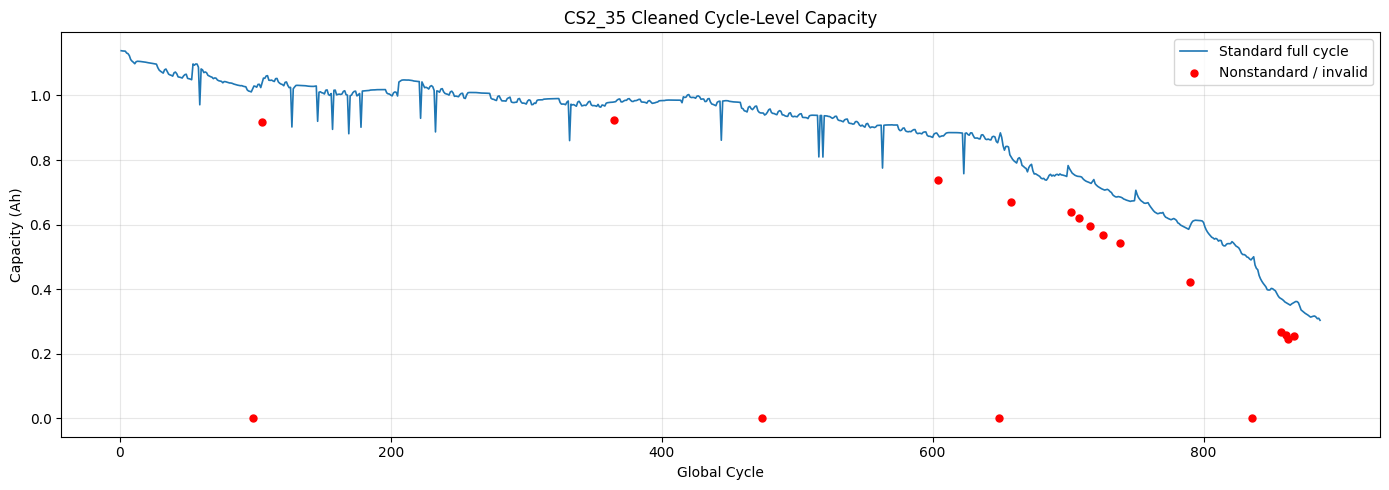

In [35]:
plt.figure(figsize=(14, 5))

standard = battery_cycles[
    battery_cycles["is_modeling_cycle"]
]

nonstandard = battery_cycles[
    ~battery_cycles["is_modeling_cycle"]
]

plt.plot(
    standard["cycle"],
    standard["capacity_ah"],
    color="tab:blue",
    linewidth=1.2,
    label="Standard full cycle",
)

plt.scatter(
    nonstandard["cycle"],
    nonstandard["capacity_ah"],
    color="red",
    s=25,
    label="Nonstandard / invalid",
    zorder=3,
)

plt.title("CS2_35 Cleaned Cycle-Level Capacity")
plt.xlabel("Global Cycle")
plt.ylabel("Capacity (Ah)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
summary = {
    "excel_file_count": len(files),
    "processed_source_file_count": (
        battery_cycles["source_file"].nunique()
    ),
    "duplicate_source_file_count": len(
        duplicate_files
    ),
    "row_count": len(battery_cycles),
    "modeling_cycle_count": int(
        battery_cycles["is_modeling_cycle"].sum()
    ),
    "nonstandard_cycle_count": int(
        (
            battery_cycles["cycle_type"]
            == "nonstandard_cycle"
        ).sum()
    ),
    "invalid_cycle_count": int(
        (
            battery_cycles["cycle_type"]
            == "invalid"
        ).sum()
    ),
}

summary

{'excel_file_count': 25,
 'processed_source_file_count': 24,
 'duplicate_source_file_count': 1,
 'row_count': 886,
 'modeling_cycle_count': 868,
 'nonstandard_cycle_count': 14,
 'invalid_cycle_count': 4}

In [37]:
CSV_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

PARQUET_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

battery_cycles.to_csv(
    CSV_OUTPUT_PATH,
    index=False,
)

battery_cycles.to_parquet(
    PARQUET_OUTPUT_PATH,
    index=False,
)

csv_check = pd.read_csv(CSV_OUTPUT_PATH)
parquet_check = pd.read_parquet(
    PARQUET_OUTPUT_PATH
)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(
    parquet_check.columns
)

print("CSV shape:", csv_check.shape)
print("Parquet shape:", parquet_check.shape)
print("02 preprocessing validation passed.")

CSV shape: (886, 30)
Parquet shape: (886, 30)
02 preprocessing validation passed.
